In [6]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import os
from math import factorial

# ----------------------------
# QSO + COSMOLOGY
# ----------------------------
RA_QSO = 357.138875
DEC_QSO = -30.9028417
REDSHIFT_QSO = 6.9

COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
ARCSEC_PER_KPC = COSMO.arcsec_per_kpc_proper(REDSHIFT_QSO)
DEG_PER_MPC = ARCSEC_PER_KPC.to(u.deg / u.Mpc)

# ----------------------------
# MASK CLASS
# ----------------------------
class Mask:
    def __init__(self, file_name: str):
        with fits.open(file_name) as hdu:
            self.data = hdu[0].data
            self.wcs = WCS(hdu[0].header)

        pixel_scales = proj_plane_pixel_scales(self.wcs) * u.deg
        self.deg_per_pix = pixel_scales[0]
        self.pix_area_deg = pixel_scales[0] * pixel_scales[1]

    def calculate_area(self, center, inner_radius, outer_radius):
        y, x = np.indices(self.data.shape)
        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        annulus = (dist >= inner_radius) & (dist <= outer_radius)
        good_pixels = (self.data > 0.5) & annulus
        return np.sum(good_pixels) * self.pix_area_deg

# ----------------------------
# Distance calculation
# ----------------------------
def calculate_distances(center, file):
    ras, decs = np.loadtxt(file, unpack=True)

    # Source to remove
    remove_ra = 358.19302900
    remove_dec = -30.94298720

    # Remove the source if it exists
    mask = ~((np.isclose(ras, remove_ra, atol=1e-6)) &
             (np.isclose(decs, remove_dec, atol=1e-6)))

    ras = ras[mask]
    decs = decs[mask]

    center_coord = SkyCoord(center[0]*u.deg, center[1]*u.deg)
    sources = SkyCoord(ras.astype(float)*u.deg, decs.astype(float)*u.deg)

    return center_coord.separation(sources)

# ----------------------------
# Surface density computation
# ----------------------------
def compute_surface_density(counts, areas):
    areas = np.array([a.value for a in areas])
    y = counts / areas
    yerr = np.sqrt(counts) / areas
    return y, yerr

# ----------------------------
# Poisson upper limits for non-detections
# ----------------------------
def poisson_upper_limit(counts, areas):
    areas = np.array([a.value for a in areas])
    y_upper = np.zeros_like(counts, dtype=float)
    for i, c in enumerate(counts):
        if c == 0:
            y_upper[i] = 1.841 / areas[i]  # Gehrels 1986
        else:
            y_upper[i] = (c + np.sqrt(c + 0.75)) / areas[i]
    return y_upper

# ----------------------------
# Poisson probability of observing LAEs given expected λ
# ----------------------------
def poisson_prob(k, lam):
    """Poisson probability P(k; λ)"""
    return (lam**k * np.exp(-lam)) / factorial(k)

def lbg_to_lae_probability(lbg_counts, lae_counts, f=0.2):
    """
    Compute expected LAEs from LBGs using scaling factor f,
    then compute Poisson probability for observed LAEs in each bin.
    """
    expected_lae = lbg_counts * f
    prob_per_bin = np.array([poisson_prob(k, lam) for k, lam in zip(lae_counts, expected_lae)])
    return expected_lae, prob_per_bin

# ----------------------------
# Debugging and plotting
# ----------------------------
def debug_and_plot(radii_mpc, radii_deg, counts_lbg, areas_lbg, counts_lae, areas_lae, outfile):
    print("\n--- DEBUG INFO ---")
    print("LBG counts per bin:", counts_lbg)
    print("LAE counts per bin:", counts_lae)
    print("Total LBGs:", np.sum(counts_lbg))
    print("Total LAEs:", np.sum(counts_lae))
    
    y_lbg, yerr_lbg = compute_surface_density(counts_lbg, areas_lbg)
    y_lae, yerr_lae = compute_surface_density(counts_lae, areas_lae)
    y_lae_upper = poisson_upper_limit(counts_lae, areas_lae)
    
    # LBG → LAE Poisson probability
    f = 0.2  # scaling factor
    expected_lae, prob_per_bin = lbg_to_lae_probability(counts_lbg, counts_lae, f=f)
    print("\nExpected LAEs per bin (λ_i from LBGs):", np.round(expected_lae, 2))
    print("Poisson probability per bin of observed LAEs:", np.round(prob_per_bin, 4))

    fig, ax = plt.subplots(figsize=(6,4), dpi=300)
    # LBGs
    ax.errorbar(radii_mpc, y_lbg, yerr=yerr_lbg, fmt='o', color='blue', ecolor='lightblue', capsize=3, label='LBGs')
    # LAEs detections
    detected = counts_lae > 0
    ax.errorbar(radii_mpc[detected], y_lae[detected], yerr=yerr_lae[detected],
                fmt='s', color='red', ecolor='pink', capsize=3, label='LAEs')
    # LAEs non-detections
    nondetected = counts_lae == 0
    ax.errorbar(radii_mpc[nondetected], y_lae_upper[nondetected],
                yerr=0.5*y_lae_upper[nondetected], fmt='v', color='red',
                uplims=True, label='LAEs upper limit')

    ax.set_yscale('log')
    ax.set_xlabel("Distance from QSO [pMpc]")
    ax.set_ylabel("Surface Density [deg$^{-2}$]")
    ax.legend()
    ax.grid(True, which='both', ls='--', lw=0.5)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(radii_mpc)
    ax2.set_xticklabels(np.round(radii_deg.value, 2))
    ax2.set_xlabel("Distance from QSO [deg]")

    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()
    print(f"Saved plot: {outfile}")

# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":
    # Catalogs
    DECAM_CATALOG = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"
    LAE_CATALOG   = "/Users/aishwarya/Desktop/lae_ra_dec_deg.txt"

    # Mask
    DECAM_MASK_FILE = "/Users/aishwarya/Desktop/Mask/trim2deg_weighted_mask_y.fits"
    decam = Mask(DECAM_MASK_FILE)
    decam_center_pix = decam.wcs.world_to_pixel_values(RA_QSO, DEC_QSO)

    # Radial bins
    BIN_WIDTH = 2
    radii_mpc = np.arange(0, 20+BIN_WIDTH, BIN_WIDTH) * u.Mpc
    radii_deg = radii_mpc * DEG_PER_MPC
    radii_pix_decam = radii_deg / decam.deg_per_pix
    radii_mid_mpc = (radii_mpc[:-1] + radii_mpc[1:]) / 2
    radii_mid_deg = radii_mid_mpc * DEG_PER_MPC

    # Compute areas
    areas_decam = [decam.calculate_area(decam_center_pix, radii_pix_decam[i], radii_pix_decam[i+1])
                   for i in range(len(radii_pix_decam)-1)]

    # Compute distances
    dist_decam = calculate_distances((RA_QSO, DEC_QSO), DECAM_CATALOG)
    dist_lae   = calculate_distances((RA_QSO, DEC_QSO), LAE_CATALOG)

    # Keep sources at zero distance (include QSO if present)
    dist_decam = dist_decam[dist_decam >= 0*u.deg]
    dist_lae   = dist_lae[dist_lae >= 0*u.deg]

    # Compute counts per bin
    counts_decam = np.array([np.sum((dist_decam >= radii_deg[i]) & (dist_decam < radii_deg[i+1]))
                             for i in range(len(radii_deg)-1)])
    counts_lae   = np.array([np.sum((dist_lae >= radii_deg[i]) & (dist_lae < radii_deg[i+1]))
                             for i in range(len(radii_deg)-1)])




-----------------------------
Input Data
-----------------------------
LBG counts: [3, 5, 8, 8, 12, 16, 16, 16, 14, 10]
LAE counts: [0, 0, 2, 3, 3, 6, 7, 4, 7, 6]

Expected LAEs (λ):
[0.9 1.5 2.4 2.4 3.6 4.8 4.8 4.8 4.2 3. ]

Poisson probability per bin [%]:
[40.657 22.313 26.127 20.901 21.247 13.98   9.586 18.203  6.859  5.041]

Joint probability:
8.878227916673284e-09

Log-likelihood:
-18.539663858790057

-----------------------------
Best Fraction
-----------------------------
Best f = 0.3515151515151515
Best log-likelihood = -18.08142726549898


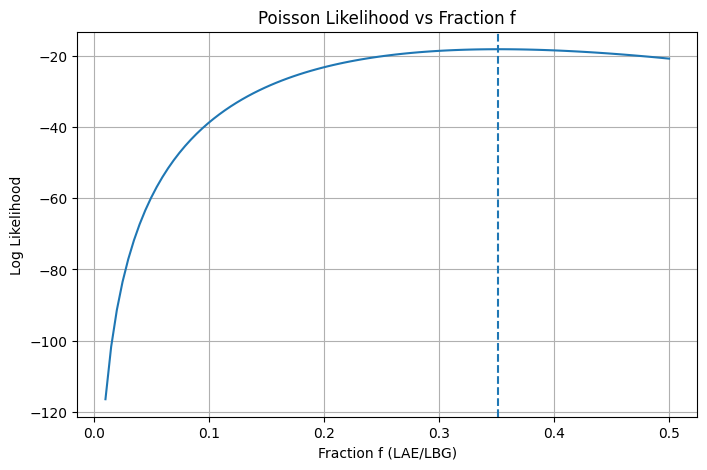

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# ---------------------------------------
# Poisson likelihood function
# ---------------------------------------
def lbg_to_lae_probabilities(lbg_counts, lae_counts, f):

    lbg_counts = np.array(lbg_counts)
    lae_counts = np.array(lae_counts)

    # Expected LAEs
    expected_lae = lbg_counts * f

    # Poisson probability per bin
    prob_per_bin = poisson.pmf(lae_counts, expected_lae)

    # Percentage
    prob_perc = prob_per_bin * 100

    # Joint probability
    joint_prob = np.prod(prob_per_bin)

    # Log likelihood
    log_likelihood = np.sum(poisson.logpmf(lae_counts, expected_lae))

    return expected_lae, prob_perc, joint_prob, log_likelihood


# ---------------------------------------
# Find best f
# ---------------------------------------
def find_best_fraction(lbg_counts, lae_counts, f_min=0.01, f_max=0.5, steps=100):

    f_values = np.linspace(f_min, f_max, steps)
    log_likelihoods = []

    for f in f_values:
        _, _, _, logL = lbg_to_lae_probabilities(lbg_counts, lae_counts, f)
        log_likelihoods.append(logL)

    log_likelihoods = np.array(log_likelihoods)

    best_index = np.argmax(log_likelihoods)
    best_f = f_values[best_index]
    best_logL = log_likelihoods[best_index]

    return f_values, log_likelihoods, best_f, best_logL


# ---------------------------------------
# Example usage
# ---------------------------------------
if __name__ == "__main__":

    lbg_counts = [3, 5, 8, 8, 12, 16, 16, 16, 14, 10]
    lae_counts = [0, 0, 2, 3, 3, 6, 7, 4, 7, 6]

    f = 0.3

    expected_lae, prob_perc, joint_prob, logL = lbg_to_lae_probabilities(
        lbg_counts, lae_counts, f
    )

    print("\n-----------------------------")
    print("Input Data")
    print("-----------------------------")
    print("LBG counts:", lbg_counts)
    print("LAE counts:", lae_counts)

    print("\nExpected LAEs (λ):")
    print(np.round(expected_lae, 2))

    print("\nPoisson probability per bin [%]:")
    print(np.round(prob_perc, 3))

    print("\nJoint probability:")
    print(joint_prob)

    print("\nLog-likelihood:")
    print(logL)

    # ---------------------------------------
    # Find best fraction
    # ---------------------------------------
    f_values, logL_values, best_f, best_logL = find_best_fraction(
        lbg_counts, lae_counts
    )

    print("\n-----------------------------")
    print("Best Fraction")
    print("-----------------------------")
    print("Best f =", best_f)
    print("Best log-likelihood =", best_logL)

    # ---------------------------------------
    # Plot likelihood
    # ---------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(f_values, logL_values)
    plt.axvline(best_f, linestyle="--")
    plt.xlabel("Fraction f (LAE/LBG)")
    plt.ylabel("Log Likelihood")
    plt.title("Poisson Likelihood vs Fraction f")
    plt.grid()
    plt.show()